# Notebook 3: Lane Comparison

LLM lane against agentic lane. VEP = validated and coverage +1 pp or mutation score +1 pp.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.normalize import build_paired_comparison
from analysis.statistics import mcnemar_test, mann_whitney_u
from analysis.plots import paired_win_loss_matrix

sns.set_theme(style='whitegrid')

DATA_DIR = Path(os.environ.get('ANALYSIS_DATA_DIR', '../../data'))
all_attempts = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv', low_memory=False)
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv', low_memory=False)
repositories = pd.read_csv(DATA_DIR / 'evaluation_repositories.csv')

# Infrastructure failures are missing data, not model or tool failures.
attempts = all_attempts[~all_attempts['infrastructure_failure'].astype(bool)]

## Headline pairs (pass@1 VEP)

Each LLM model's `PassAt1` arm against the agentic tool running the same model.

GLM-5.3-thinking-high vs openhands-custom-glm: 4 pairs, 2 discordant (discordant pairs: n01=2, n10=0); exact p = 0.500, smallest reachable 0.500
gpt-5.6-luna vs copilot-openai: 4 pairs, 1 discordant (discordant pairs: n01=1, n10=0); exact p = 1.000, smallest reachable 1.000


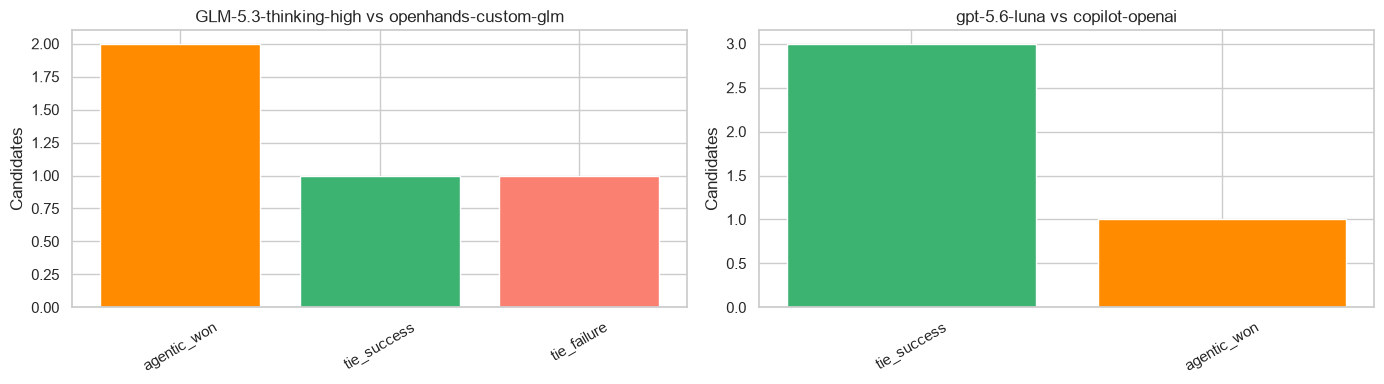

In [2]:
PAIRS = [('GLM-5.3-thinking-high', 'openhands-custom-glm'), ('gpt-5.6-luna', 'copilot-openai')]
OUTCOME = 'first_attempt_positive_impact'

fig, axes = plt.subplots(1, len(PAIRS), figsize=(7 * len(PAIRS), 4), squeeze=False)
for ax, (llm_producer, tool) in zip(axes[0], PAIRS):
    paired = build_paired_comparison(candidates, llm_producer, tool, OUTCOME, llm_budget_mode='PassAt1')
    paired_win_loss_matrix(paired, ax=ax)
    ax.set_title(f'{llm_producer} vs {tool}')
    both = paired[paired['winner'].isin(['llm_won', 'agentic_won', 'tie_success', 'tie_failure'])]
    discordant = int(both['winner'].isin(['llm_won', 'agentic_won']).sum())
    result = mcnemar_test(both['llm_success'], both['agentic_success'])
    # With d discordant pairs the smallest two-sided exact p is 2 * 0.5**d.
    print(f'{llm_producer} vs {tool}: {len(both)} pairs, {discordant} discordant ({result.note}); '
          f'exact p = {result.p_value:.3f}, smallest reachable {min(2 * 0.5 ** discordant, 1.0):.3f}')
plt.tight_layout()
plt.show()

## Chain-weighted rates

In [3]:
rates = {col: candidates.dropna(subset=[col]).groupby(['lane', 'budget_mode'])[col]
               .apply(lambda s: s.astype(bool).mean())
         for col in ['first_attempt_success', 'first_attempt_positive_impact',
                     'any_validated_success', 'any_positive_impact']}
display(pd.DataFrame(rates).round(3))

first_attempt_success  \
lane    budget_mode                               
agentic PassAt1                           0.788   
llm     PassAt1                           0.722   
        PassAt1RepairAt5                  0.778   

                          first_attempt_positive_impact  \
lane    budget_mode                                       
agentic PassAt1                                   0.683   
llm     PassAt1                                   0.611   
        PassAt1RepairAt5                          0.667   

                          any_validated_success  any_positive_impact  
lane    budget_mode                                                   
agentic PassAt1                           0.788                0.683  
llm     PassAt1                           0.722                0.611  
        PassAt1RepairAt5                  0.944                0.778

## Attempt-weighted rates

In [4]:
display(attempts.groupby('lane')[['validated_success', 'validated_evidence_positive']]
        .agg(['sum', 'mean']).round(3))

# x = LLM, y = agentic: Cliff's delta > 0 means LLM deltas are larger.
llm_d = attempts.loc[attempts['lane'] == 'llm', 'coverage_delta'].dropna()
ag_d = attempts.loc[attempts['lane'] == 'agentic', 'coverage_delta'].dropna()
result = mann_whitney_u(llm_d, ag_d)
print(f"Mann-Whitney U (coverage_delta): U={result.statistic:.1f}, p={result.p_value:.4f}, "
      f"n={result.n}, Cliff's delta={result.effect_size:.3f}")

validated_success        validated_evidence_positive       
                      sum   mean                         sum   mean
lane                                                               
agentic                82  0.788                          71  0.683
llm                    34  0.630                          25  0.463

Mann-Whitney U (coverage_delta): U=1252.0, p=0.0478, n=124, Cliff's delta=-0.222


## Repository-weighted rates

In [5]:
display(repositories.pivot_table(index='repo_name', columns='lane',
                                 values=['validated_success_rate', 'positive_impact_rate']).round(3))

positive_impact_rate        validated_success_rate       
lane                              agentic    llm                agentic    llm
repo_name                                                                     
aspectcore-framework                0.385  0.400                  0.615  0.900
gridify                             0.808  1.000                  0.846  1.000
serilog-expressions                 0.680  0.500                  0.760  0.500
zstring                             0.852  0.875                  0.926  0.875

## Cost-effectiveness

In [6]:
spm = attempts.groupby('lane').apply(
    lambda g: g['validated_success'].sum() / (g['duration_seconds'].sum() / 60))
# Chains without recorded usage are left out; counting them as free would inflate their lane.
costed = candidates[candidates['effective_tokens'].notna() & candidates['any_validated_success'].notna()]
spk = costed.groupby('lane').apply(
    lambda g: g['any_validated_success'].astype(bool).sum() / (g['effective_tokens'].sum() / 1000))
display(pd.DataFrame({'successes_per_minute': spm, 'successes_per_1k_tokens': spk,
                      'chains_with_usage': costed.groupby('lane').size()}).round(4))

,successes_per_minute,successes_per_1k_tokens,chains_with_usage
lane,,,
agentic,0.0343,0.0017,57
llm,0.0217,0.0760,36
